<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   id                          30000 non-null  int64
 1   limit_bal                   30000 non-null  int64
 2   sex                         30000 non-null  int64
 3   education                   30000 non-null  int64
 4   marriage                    30000 non-null  int64
 5   age                         30000 non-null  int64
 6   pay_0                       30000 non-null  int64
 7   pay_2                       30000 non-null  int64
 8   pay_3                       30000 non-null  int64
 9   pay_4                       30000 non-null  int64
 10  pay_5                       30000 non-null  int64
 11  pay_6                       30000 non-null  int64
 12  bill_amt1                   30000 non-null  int64
 13  bill_amt2                   30000 non-null  int64
 14  bill_amt3        

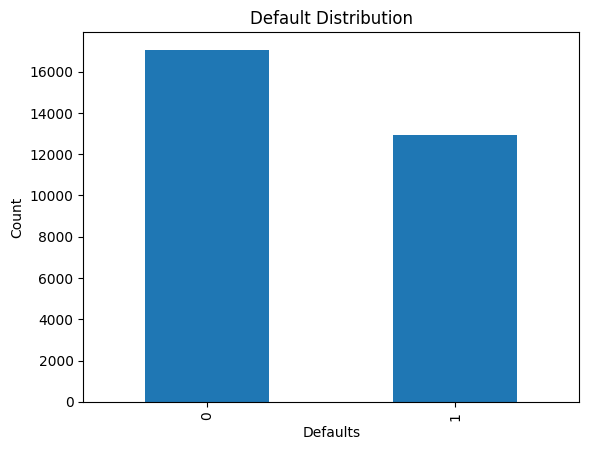

Imbalance Ratio: 1.32:1
Done


In [14]:
%run data_exploration.ipynb
print("Done")

In [15]:
import numpy as np

In [16]:
bill_cols = [
    "bill_amt1","bill_amt2","bill_amt3",
    "bill_amt4","bill_amt5","bill_amt6"
]


In [17]:
payment_cols=[
    'pay_amt1','pay_amt2','pay_amt3','pay_amt4','pay_amt5','pay_amt6'
]

**Feature Engineering**

In [18]:
# df["avg_bill"] = df[bill_cols].mean(axis=1)
# df["average_payment"]=df[payment_cols].mean(axis=1)

# df["repayment_ratio"] = (
#     df["pay_amt1"] /
#     (df["bill_amt1"].abs() + 1)
# )


In [19]:
for col in df.columns:
    inf_count = np.isinf(df[col]).sum()
    nan_count = df[col].isna().sum()

    if inf_count > 0 or nan_count > 0:
        print(f"{col}: Inf={inf_count}, NaN={nan_count}")

**Feature importance**

In [20]:
# importance = pd.DataFrame({
#     "feature": X.columns,
#     "importance": model.feature_importances_
# })

# print(importance.sort_values("importance", ascending=False).head(20))

**Training Random forest and Logistic Regression**

In [21]:
import pandas as pd
import numpy as np
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# Example: load processed dataset
df = df.copy()

target_col = "default_payment_next_month"

# Remove IDs and target from features
drop_cols = [target_col]
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df[target_col]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

models = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "random_forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    
    results[name] = {
        "roc_auc": roc_auc_score(y_test, y_prob),
        "average_precision": average_precision_score(y_test, y_prob),
        "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "pipeline": pipeline
    }

for name, result in results.items():
    print(name)
    print("ROC AUC:", result["roc_auc"])
    print("Average Precision:", result["average_precision"])
    print()

logistic_regression
ROC AUC: 0.8974244257128716
Average Precision: 0.8772617208173301

random_forest
ROC AUC: 0.8713356544540027
Average Precision: 0.8479650550910134



In [22]:
best_model_name = max(results, key=lambda name: results[name]["roc_auc"])
best_pipeline = results[best_model_name]["pipeline"]

print("Best model:", best_model_name)

Best model: logistic_regression


In [23]:
joblib.dump(best_pipeline, "credit_risk_model.joblib")

['credit_risk_model.joblib']

**Confusison Matrix**

In [24]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[2702  709]
 [ 615 1974]]


TP  FN
FP  TN

**Classification Report**

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80      3411
           1       0.74      0.76      0.75      2589

    accuracy                           0.78      6000
   macro avg       0.78      0.78      0.78      6000
weighted avg       0.78      0.78      0.78      6000



**ROC-AUC SCORE**

In [26]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

0.8713356544540027